This notebook was created by Donna Faith Go.

In [1]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import re

# pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear

# ignore warnings
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

## Temporal Graph Convolutional Network

In [2]:
class GCNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(in_channels, out_channels)
        
    def forward(self, x, adj):
        if adj.dim() == 2:
            adj = adj.unsqueeze(0).expand(x.size(0), -1, -1)
        support = self.linear(x)
        output = torch.bmm(adj, support)
        return output

In [3]:
class TGCNCell(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(TGCNCell, self).__init__()
        self.hidden_channels = hidden_channels
        self.in_channels = in_channels
        self.gcn_reset = GCNLayer(in_channels + hidden_channels, hidden_channels)
        self.gcn_update = GCNLayer(in_channels + hidden_channels, hidden_channels)
        self.gcn_candidate = GCNLayer(in_channels + hidden_channels, hidden_channels)
        
    def forward(self, x, adj, h):
        combined = torch.cat([x, h], dim=-1)
        r = torch.sigmoid(self.gcn_reset(combined, adj))
        z = torch.sigmoid(self.gcn_update(combined, adj))
        combined_reset = torch.cat([x, r * h], dim=-1)
        h_tilde = torch.tanh(self.gcn_candidate(combined_reset, adj))
        h_new = (1 - z) * h + z * h_tilde
        return h_new

In [4]:
class TGCNLayer(nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.3):
        super(TGCNLayer, self).__init__()
        self.tgcn_cell = TGCNCell(in_channels, hidden_channels)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.LeakyReLU()
        self.norm = nn.LayerNorm(hidden_channels)
        
    def forward(self, x_seq, adj):
        batch_size, time_steps, num_nodes, _ = x_seq.shape
        h = torch.zeros(batch_size, num_nodes, self.tgcn_cell.hidden_channels, device=x_seq.device)
        outputs = []
        for t in range(time_steps):
            h = self.tgcn_cell(x_seq[:, t, :, :], adj, h)
            h = self.activation(h)
            h = self.norm(h)
            h = self.dropout(h)
            outputs.append(h)
        return torch.stack(outputs, dim=1)

In [5]:
class TGCNModel(nn.Module):
    def __init__(self, num_nodes=498, in_channels=1, hidden_channels=128, 
                 num_layers=8, dropout=0.3, time_steps=10):
        super(TGCNModel, self).__init__()
        self.num_nodes = num_nodes
        self.time_steps = time_steps
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.tgcn_layers = nn.ModuleList()
        for i in range(num_layers):
            layer_input_channels = hidden_channels if i > 0 else hidden_channels
            self.tgcn_layers.append(
                TGCNLayer(layer_input_channels, hidden_channels, dropout)
            )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
        self.reset_parameters()
        
    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def forward(self, x_seq, adj):
        batch_size = x_seq.size(0)
        x_seq = self.input_proj(x_seq)
        h = x_seq
        for i, layer in enumerate(self.tgcn_layers):
            h_new = layer(h, adj)
            if i > 0 and i % 2 == 1:
                if h.shape == h_new.shape:
                    h = h + h_new
                else:
                    h = h_new
            else:
                h = h_new
        final_hidden = h[:, -1, :, :]
        return final_hidden
    
    def predict_links(self, node_embeddings, edge_pairs):
        batch_size = node_embeddings.size(0)
        src_nodes = edge_pairs[:, 0]
        dst_nodes = edge_pairs[:, 1]
        src_emb = node_embeddings[:, src_nodes, :]
        dst_emb = node_embeddings[:, dst_nodes, :]
        edge_features = torch.cat([src_emb, dst_emb], dim=-1)
        logits = self.decoder(edge_features).squeeze(-1)
        return logits

## Training the TGCN

In [6]:
class Trainer:
    def __init__(self, model, lr=0.001, weight_decay=1e-5, device='cuda'):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterion = nn.BCEWithLogitsLoss()
        
    def train_epoch(self, train_loader, val_loader=None, negative_sampling_ratio=1.0):
        self.model.train()
        total_loss = 0
        for batch in train_loader:
            x_seq, adj, pos_edges, neg_edges = batch
            x_seq = x_seq.to(self.device)
            adj = adj.to(self.device)
            node_embeddings = self.model(x_seq, adj)
            all_edges = torch.cat([pos_edges, neg_edges], dim=0)
            all_labels = torch.cat([
                torch.ones(pos_edges.size(0)),
                torch.zeros(neg_edges.size(0))
            ]).to(self.device)
            logits = self.model.predict_links(node_embeddings, all_edges)
            loss = self.criterion(logits, all_labels)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    
    def evaluate(self, loader):
        self.model.eval()
        all_logits = []
        all_labels = []
        with torch.no_grad():
            for batch in loader:
                x_seq, adj, pos_edges, neg_edges = batch
                x_seq = x_seq.to(self.device)
                adj = adj.to(self.device)
                node_embeddings = self.model(x_seq, adj)
                all_edges = torch.cat([pos_edges, neg_edges], dim=0)
                all_labels_batch = torch.cat([
                    torch.ones(pos_edges.size(0)),
                    torch.zeros(neg_edges.size(0))
                ])
                logits = self.model.predict_links(node_embeddings, all_edges)
                all_logits.append(logits.cpu())
                all_labels.append(all_labels_batch)
        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)
        probs = torch.sigmoid(all_logits)
        from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
        auc_roc = roc_auc_score(all_labels.numpy(), probs.numpy())
        auc_pr = average_precision_score(all_labels.numpy(), probs.numpy())
        preds = (probs > 0.5).float()
        f1 = f1_score(all_labels.numpy(), preds.numpy())
        return {
            'auc_roc': auc_roc,
            'auc_pr': auc_pr,
            'f1': f1
        }

In [7]:
def create_model_from_table(num_nodes=498, time_steps=10):
    model = TGCNModel(
        num_nodes=num_nodes,
        in_channels=1,
        hidden_channels=128,
        num_layers=8,
        dropout=0.3,
        time_steps=time_steps
    )
    return model

## Supplementary

### Sanity Checks

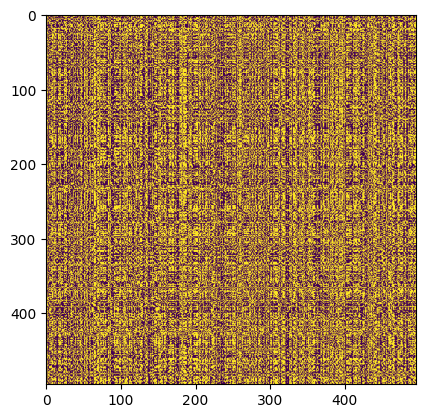

In [8]:
filepath = r'adjacency matrices/2000-03-08.pkl'
with open(filepath, 'rb') as f:
    data = pickle.load(f)
df = pd.DataFrame(data['adjacency matrix'])

# plotting
plt.imshow(df)
plt.show()